# OpenStitching Baseline — One Pair Stitching 




In [ ]:
# --- Paths (edit if needed) ---
from pathlib import Path

PROJECT_ROOT = Path(".")  # set to your repo root if running elsewhere
TESTING_DIR = PROJECT_ROOT / "testing"
INPUT1_DIR = TESTING_DIR / "input1"
INPUT2_DIR = TESTING_DIR / "input2"
RESULT_DIR = PROJECT_ROOT / "result"

# Optional: if your repo uses "results" instead of "result", just change RESULT_DIR.
print("INPUT1_DIR:", INPUT1_DIR.resolve())
print("INPUT2_DIR:", INPUT2_DIR.resolve())
print("RESULT_DIR:", RESULT_DIR.resolve())

RESULT_DIR.mkdir(parents=True, exist_ok=True)


In [ ]:
# --- Load one pair (pick first image in input1, match by same filename in input2) ---
import glob
import os

# Supported image extensions
exts = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff", "*.webp")

input1_files = []
for e in exts:
    input1_files += glob.glob(str(INPUT1_DIR / e))
input1_files = sorted(input1_files)

if len(input1_files) == 0:
    raise FileNotFoundError(f"No images found in {INPUT1_DIR}. Put test images there first.")

img1_path = Path(input1_files[0])
img2_path = INPUT2_DIR / img1_path.name  # "corresponding" = same filename

if not img2_path.exists():
    # Fallback: try same stem with any extension in input2
    candidates = []
    for e in exts:
        candidates += glob.glob(str(INPUT2_DIR / (img1_path.stem + e.replace('*',''))))
    if len(candidates) == 0:
        raise FileNotFoundError(
            f"Couldn't find corresponding image in {INPUT2_DIR}.\n"
            f"Expected: {img2_path}\n"
            f"Tip: make sure input1 and input2 contain matching filenames."
        )
    img2_path = Path(sorted(candidates)[0])

print("Selected pair:")
print(" - img1:", img1_path)
print(" - img2:", img2_path)


In [ ]:
# --- Read images ---
import cv2
import numpy as np

img1 = cv2.imread(str(img1_path))
img2 = cv2.imread(str(img2_path))

if img1 is None:
    raise ValueError(f"cv2.imread failed for {img1_path}")
if img2 is None:
    raise ValueError(f"cv2.imread failed for {img2_path}")

print("img1 shape:", img1.shape, "dtype:", img1.dtype)
print("img2 shape:", img2.shape, "dtype:", img2.dtype)


In [ ]:
# --- Run baseline OpenStitching ---
# Make sure you've installed the repo/package:
#   pip install -e .
#
# If this import fails, run the install command above from the repo root.

from stitching import Stitcher

stitcher = Stitcher()  # baseline defaults
panorama = stitcher.stitch([img1, img2])

if panorama is None:
    raise RuntimeError("Stitcher returned None (stitching failed). Try a pair with more overlap.")

print("panorama shape:", panorama.shape, "dtype:", panorama.dtype)


In [ ]:
# --- Save output to result/ ---
out_name = f"stitched_{img1_path.stem}.jpg"
out_path = RESULT_DIR / out_name

# Ensure uint8 for saving
if panorama.dtype != np.uint8:
    pano_to_save = np.clip(panorama, 0, 255).astype(np.uint8)
else:
    pano_to_save = panorama

ok = cv2.imwrite(str(out_path), pano_to_save)
if not ok:
    raise RuntimeError(f"cv2.imwrite failed for {out_path}")

print("Saved:", out_path.resolve())


In [ ]:
# --- Visualize (optional) ---
import matplotlib.pyplot as plt

def bgr_to_rgb(x):
    return cv2.cvtColor(x, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(16,5))
plt.subplot(1,3,1); plt.title("Input1"); plt.axis("off"); plt.imshow(bgr_to_rgb(img1))
plt.subplot(1,3,2); plt.title("Input2"); plt.axis("off"); plt.imshow(bgr_to_rgb(img2))
plt.subplot(1,3,3); plt.title("Stitched"); plt.axis("off"); plt.imshow(bgr_to_rgb(pano_to_save))
plt.show()



- overlap mask extraction
- SSIM / PSNR on overlap
- gradient seam energy
- runtime & memory profiling
and save all metrics to CSV in `result/`.


Saved testing/results/000001_stitched.jpg
Saved testing/results/000002_stitched.jpg
Saved testing/results/000003_stitched.jpg
Saved testing/results/000004_stitched.jpg
Saved testing/results/000005_stitched.jpg
Saved testing/results/000006_stitched.jpg
Saved testing/results/000007_stitched.jpg
Saved testing/results/000008_stitched.jpg
Saved testing/results/000009_stitched.jpg
Saved testing/results/000010_stitched.jpg
Saved testing/results/000011_stitched.jpg
Saved testing/results/000012_stitched.jpg
Saved testing/results/000013_stitched.jpg
Saved testing/results/000014_stitched.jpg
Saved testing/results/000015_stitched.jpg
Saved testing/results/000016_stitched.jpg
Saved testing/results/000017_stitched.jpg
Saved testing/results/000018_stitched.jpg
Saved testing/results/000019_stitched.jpg
Saved testing/results/000020_stitched.jpg
Saved testing/results/000021_stitched.jpg
Saved testing/results/000022_stitched.jpg
Saved testing/results/000023_stitched.jpg
Saved testing/results/000024_stitc

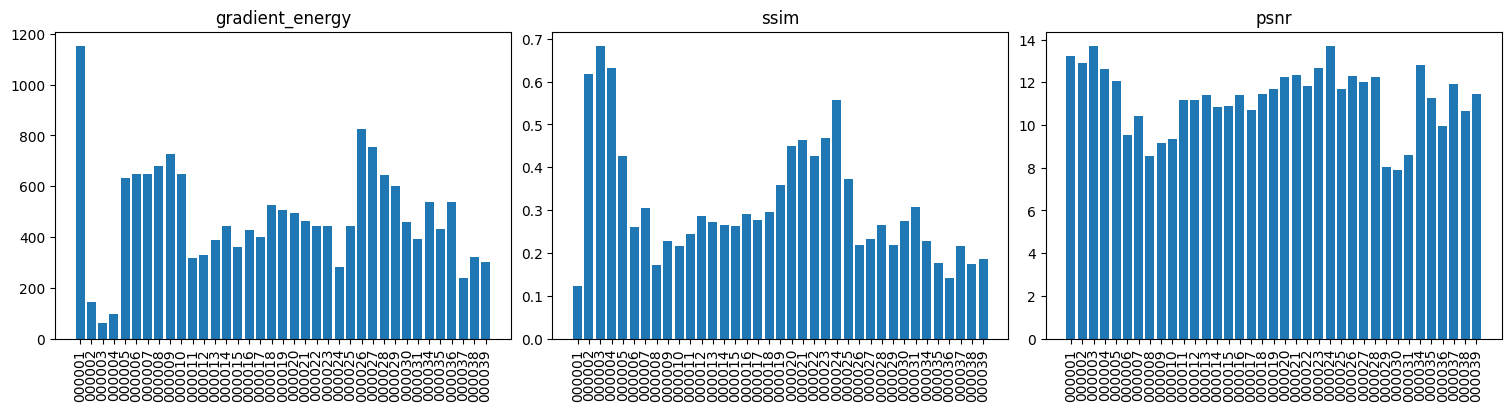

name   | gradient_energy | ssim   | psnr   
-------+-----------------+--------+--------
000001 | 1150.8308       | 0.1238 | 13.2261
000002 | 142.0821        | 0.6179 | 12.8872
000003 | 60.2281         | 0.6823 | 13.6886
000004 | 97.2573         | 0.6316 | 12.6109
000005 | 630.9791        | 0.4259 | 12.0814
000006 | 646.5809        | 0.2599 | 9.5239 
000007 | 647.0426        | 0.3053 | 10.4047
000008 | 677.5409        | 0.1725 | 8.5597 
000009 | 728.4111        | 0.2271 | 9.1629 
000010 | 649.1105        | 0.2150 | 9.3687 
000011 | 318.0090        | 0.2444 | 11.1752
000012 | 329.9667        | 0.2854 | 11.1793
000013 | 388.6965        | 0.2711 | 11.4061
000014 | 441.8541        | 0.2641 | 10.8571
000015 | 359.2840        | 0.2629 | 10.8899
000016 | 425.7284        | 0.2900 | 11.4293
000017 | 400.1386        | 0.2760 | 10.7162
000018 | 523.8466        | 0.2953 | 11.4514
000019 | 504.7093        | 0.3579 | 11.6960
000020 | 493.6839        | 0.4485 | 12.2705
000021 | 462.8858        | 0.463

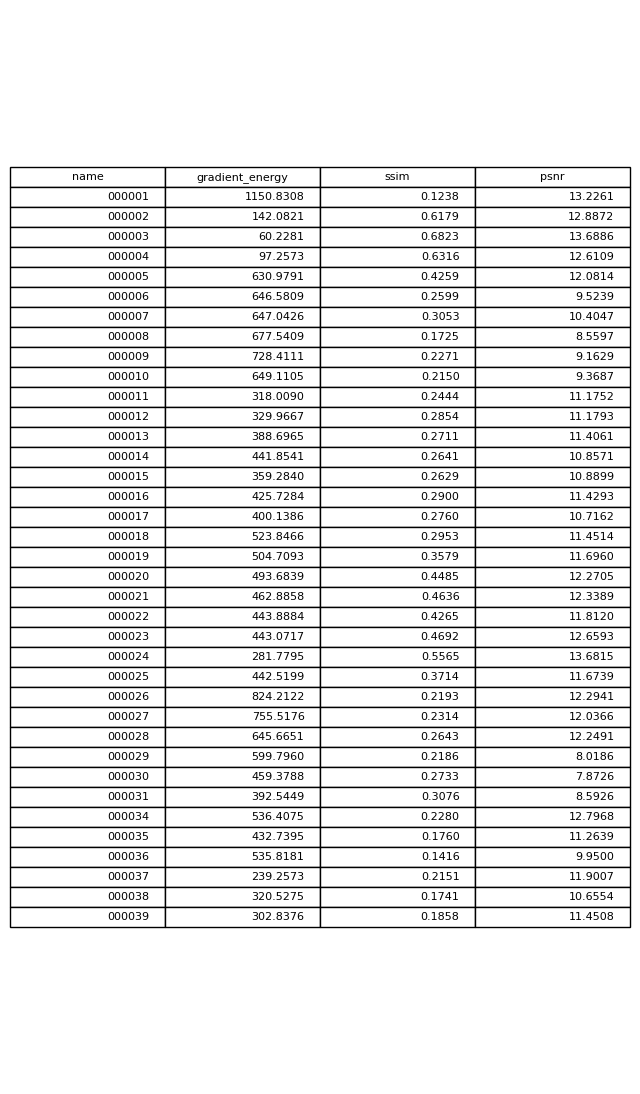

In [1]:
# Stitch paired frames from testing/input1 and testing/input2 into testing/results
from pathlib import Path
import cv2 as cv
import numpy as np
from skimage.metrics import structural_similarity, peak_signal_noise_ratio
import matplotlib.pyplot as plt

from stitching import Stitcher

INPUT1_DIR = Path('testing/input1')
INPUT2_DIR = Path('testing/input2')
OUTPUT_DIR = Path('testing/results')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
REFERENCE_DIR = Path('testing/Ours')
DEFAULT_MAX_PAIRS = 39  # stop at 31st image as requested

def available_pairs():
    names1 = {p.name for p in INPUT1_DIR.glob('*.jpg')}
    names2 = {p.name for p in INPUT2_DIR.glob('*.jpg')}
    return sorted(names1 & names2)

def gradient_energy(img: np.ndarray) -> float:
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    lap = cv.Laplacian(gray, cv.CV_64F)
    return float(lap.var())

def evaluate_against_reference(pano: np.ndarray, name: str, ref_dir: Path = REFERENCE_DIR):
    stem = Path(name).stem
    candidates = [ref_dir / f"{stem}.jpg", ref_dir / f"{stem}_stitched.jpg"]
    ref_path = next((p for p in candidates if p.exists()), None)
    if ref_path is None:
        return None
    ref = cv.imread(str(ref_path))
    if ref is None:
        return None
    if ref.shape != pano.shape:
        ref = cv.resize(ref, (pano.shape[1], pano.shape[0]), interpolation=cv.INTER_LINEAR)
    ssim = structural_similarity(ref, pano, channel_axis=2)
    psnr = peak_signal_noise_ratio(ref, pano, data_range=255)
    return {'ssim': float(ssim), 'psnr': float(psnr)}

def stitch_pairs(pair_names=None, max_pairs: int = DEFAULT_MAX_PAIRS, medium_megapix: float = 0.6):
    """Stitch matching filenames from input1 & input2; saves to testing/results.

    Args:
        pair_names: iterable of filenames (e.g., ['000002.jpg']); when None, stitches all matches.
        max_pairs: optional cap on how many pairs to process.
        medium_megapix: optional downscale megapixels; 0.6 default MEDIUM.
    Returns:
        (outputs dict, metrics list)
    """
    names = available_pairs() if pair_names is None else [n for n in pair_names if (INPUT1_DIR / n).exists() and (INPUT2_DIR / n).exists()]
    if max_pairs is not None:
        names = names[:max_pairs]
    if not names:
        print('No matching pairs found to stitch.')
        return {}, []
    stitcher = Stitcher(medium_megapix=medium_megapix)
    outputs = {}
    metrics = []
    for name in names:
        paths = [str(INPUT1_DIR / name), str(INPUT2_DIR / name)]
        try:
            pano = stitcher.stitch(paths)
        except Exception as exc:
            print(f'Skip {name}: {exc}')
            continue
        out_path = OUTPUT_DIR / f"{Path(name).stem}_stitched.jpg"
        cv.imwrite(str(out_path), pano)
        outputs[name] = out_path
        ref_scores = evaluate_against_reference(pano, name)
        entry = {
            'name': name,
            'gradient_energy': gradient_energy(pano),
        }
        if ref_scores:
            entry.update(ref_scores)
        metrics.append(entry)
        print(f'Saved {out_path}')
    if metrics:
        _plot_metrics(metrics)
        _print_metrics_table(metrics)
        _save_metrics_table_image(metrics)
    return outputs, metrics

def _plot_metrics(metrics):
    keys = [k for k in metrics[0].keys() if k != 'name']
    names = [m['name'] for m in metrics]
    fig, axs = plt.subplots(1, len(keys), figsize=(5*len(keys), 4), constrained_layout=True)
    if len(keys) == 1:
        axs = [axs]
    for ax, key in zip(axs, keys):
        values = [m.get(key, np.nan) for m in metrics]
        ax.bar(range(len(names)), values)
        ax.set_title(key)
        ax.set_xticks(range(len(names)))
        ax.set_xticklabels([Path(n).stem for n in names], rotation=90)
    plt.show()


def _print_metrics_table(metrics):
    keys = [k for k in metrics[0].keys() if k != 'name']
    header = ['name'] + keys
    rows = []
    for m in metrics:
        row = [Path(m['name']).stem]
        for k in keys:
            val = m.get(k, np.nan)
            row.append(f"{val:.4f}" if isinstance(val, (int, float)) else str(val))
        rows.append(row)
    col_widths = [max(len(str(item)) for item in col) for col in zip(header, *rows)]
    def fmt_row(items):
        return ' | '.join(str(item).ljust(w) for item, w in zip(items, col_widths))
    print(fmt_row(header))
    print('-+-'.join('-' * w for w in col_widths))
    for r in rows:
        print(fmt_row(r))

def _save_metrics_table_image(metrics):
    keys = [k for k in metrics[0].keys() if k != 'name']
    rows = []
    for m in metrics:
        row = [Path(m['name']).stem]
        for k in keys:
            val = m.get(k, np.nan)
            row.append(f"{val:.4f}" if isinstance(val, (int, float)) else str(val))
        rows.append(row)
    fig, ax = plt.subplots(figsize=(max(8, 1.2 * len(keys) + 4), max(3, 0.35 * len(rows) + 1)))
    ax.axis('off')
    table = ax.table(cellText=rows, colLabels=['name'] + keys, loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1, 1.2)
    out_path = OUTPUT_DIR / 'metrics_table.png'
    plt.savefig(out_path, dpi=200, bbox_inches='tight')
    plt.show()
# Stitch the first 31 matching pairs by default and plot metrics
pair_outputs, pair_metrics = stitch_pairs(max_pairs=DEFAULT_MAX_PAIRS)
